# CNN ENTRENAMIENTO

### Callback de Accuracy (Keras)

In [1]:
from dataclasses import dataclass
from datetime import datetime

@dataclass
class MetricsValue:
    value: float
    value_name: str

@dataclass
class MetricsDto:
    name: str
    timestamp: datetime
    step: int
    step_type: str
    phase: str
    values: list[MetricsValue]

In [2]:
import tensorflow as tf
import json
import paho.mqtt.client as mqtt
import csv
import os
from datetime import datetime
from dataclasses import asdict

folder = "AccuracyFiles"
os.makedirs(folder, exist_ok=True)

filename = folder + "/Accuracy_" + datetime.now().strftime("%Y%m%d") + ".csv"

class AccuracyCallback(tf.keras.callbacks.Callback):
    def __init__(self, epoch_offset=0):
        self.offset = epoch_offset
        try:
            self.mqtt_client = mqtt.Client()
            broker = "localhost"
            port = 1883
            self.mqtt_client.connect(broker, port)
            self.mqtt_client.loop_start()

        except Exception as e:
            print(f"Error conectando con el broker: {e}")
            self.mqtt = None

    def on_epoch_end(self, epoch, logs=None,  ):
        now = datetime.now().isoformat()
        train_dto = MetricsDto(
            name= "CNN",
            timestamp=now,
            step=epoch + self.offset,
            step_type="epoch",
            phase="train",
            values=[
                MetricsValue(value=float(logs.get("accuracy", 0.0)), value_name="accuracy"),
                MetricsValue(value=float(logs.get("loss", 0.0)), value_name="loss (scc)")
            ]
        )
        val_dto = MetricsDto(
        name= "CNN",
        timestamp=now,
        step=epoch + self.offset,
        step_type="epoch",
        phase="val",
        values=[
            MetricsValue(value=float(logs.get("val_accuracy", 0.0)), value_name="accuracy"),
            MetricsValue(value=float(logs.get("val_loss", 0.0)), value_name="loss (scc)")
        ]
        )
        self.mqtt_client.publish("training/metrics", json.dumps(asdict(train_dto)), qos=1)
        self.mqtt_client.publish("training/metrics", json.dumps(asdict(val_dto)), qos=1)


    def save_data(self, data):
        with open(filename, "a", newline="") as file:
            writer = csv.writer(file)
            writer.writerow([datetime.now().strftime("%Y%m%d-%H%M"), data["epoch"], data["accuracy"]])




### 1. Resnet50 con Transfer Learning

Dataset: RealWaste

Idea: Probar transfer learning descongelando distinto número de capas y observar el trade-off entre Accuracy y consumo. Mantener constante el entrenamiento de la FC.

(Potencialmente podría mirar variando las epochs de entrenamiento de la FC)

1.1 Entrenamiento

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

# Alternativa por si ResNet50 es demasiado pesado 

In [2]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50 
from tensorflow.keras.applications.resnet50 import preprocess_input


layers = tf.keras.layers
models = tf.keras.models
utils = tf.keras.utils

directory = 'datasets/realwaste-main/RealWaste/'

train_dataset = utils.image_dataset_from_directory(
    directory,
    labels="inferred",
    class_names=None,
    subset="training",
    validation_split=0.2,
    batch_size=32,
    image_size=(224,224),
    shuffle=True,
    seed=12,
)

validation_dataset = utils.image_dataset_from_directory(
    directory,
    labels="inferred",
    class_names=None,
    subset="validation",
    validation_split=0.2,
    batch_size=32,
    image_size=(224,224),
    shuffle=True,
    seed=12,
)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.15),
])

resnet_model = ResNet50(
    weights = "imagenet",
    include_top=False, # eliminar la capa final para adaptarlo al dataset y categorizar como corresponda 
    input_shape=(224,224,3)
)

resnet_model.trainable = False

inputs = tf.keras.Input(shape=(224,224,3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = resnet_model(x , training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(9, activation="softmax")(x) 
model = models.Model(inputs, outputs)

model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# Entrenar última capa
print("Starting training of FC layer")
history = model.fit(train_dataset, validation_data=validation_dataset, epochs=5, callbacks=[AccuracyCallback()])

# Descongelar capas finales
resnet_model.trainable = True
for layer in resnet_model.layers[:-10]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# Finetune
print("Starting finetuning training")
history = model.fit(train_dataset, validation_data=validation_dataset, epochs=5, callbacks=[AccuracyCallback()])
    

# Evaluar CNN
test_loss, test_acc = model.evaluate(validation_dataset)
print("\nCNN - Test accuracy:", test_acc)


Found 4752 files belonging to 9 classes.
Using 3802 files for training.
Found 4752 files belonging to 9 classes.
Using 950 files for validation.
Starting training of FC layer



KeyboardInterrupt



1.2 Validación visual

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

class_names = validation_dataset.class_names

for images, labels in validation_dataset.take(1):  # coge un batch
    images = images.numpy()
    labels = labels.numpy()

idxs = np.random.choice(len(images), 5, replace=False)

for i in idxs:
    img = images[i].astype("uint8")
    label = labels[i]

    img_input = np.expand_dims(images[i], axis=0)
    pred = np.argmax(model.predict(img_input, verbose=0))

    plt.imshow(img)
    plt.title(f"Pred: {class_names[pred]} | Real: {class_names[label]}")
    plt.axis("off")
    plt.show()

### 2. CNN propia

Dataset:

Idea: Probar una red convolucional utilizando diferente número de epochs y observando la relación entre el consumo y accuracy, tratando de determinar el final del periodo crítico y entender cuando deja de ser eficiente seguir entrenando. Posibilidad de quizás probar a reducir a partir de X punto (considerado el periodo crítico) la cantidad de recursos del entrenamiento para observar si la reducción de recursos impacta positivamente en el consumo sin producir un detrimento en el accuracy.

In [5]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

layers = tf.keras.layers
models = tf.keras.models
utils = tf.keras.utils

directory = 'datasets/realwaste-main/RealWaste/'

train_dataset = utils.image_dataset_from_directory(
    directory,
    labels="inferred",
    class_names=None,
    subset="training",
    validation_split=0.2,
    batch_size=32,
    image_size=(256,256),
    shuffle=True,
    seed=12,
)

validation_dataset = utils.image_dataset_from_directory(
    directory,
    labels="inferred",
    class_names=None,
    subset="validation",
    validation_split=0.2,
    batch_size=32,
    image_size=(256,256),
    shuffle=True,
    seed=12,
)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.15),
])

class_names = train_dataset.class_names
num_classes = len(class_names)

# Normalizar a [0,1]
normalization_layer = layers.Rescaling(1./255)
train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
validation_dataset = validation_dataset.map(lambda x, y: (normalization_layer(x), y))

# Definir modelo CNN
inputs = tf.keras.Input(shape=(256,256,3))
x = data_augmentation(inputs)
x = layers.Conv2D(16, (3,3), activation='relu')(x)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Conv2D(32, (3,3), activation='relu')(x)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Conv2D(64, (3,3), activation='relu')(x)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Conv2D(128, (3,3), activation='relu')(x)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Flatten()(x)
x = layers.Dense(64, activation='relu')(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs=inputs, outputs=outputs)
model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# Entrenar CNN
history = model.fit(train_dataset, validation_data=validation_dataset, epochs=8, batch_size=64, callbacks=[AccuracyCallback()])

# Evaluar CNN
test_loss, test_acc = model.evaluate(validation_dataset)
print("\nCNN - Test accuracy:", test_acc)

Found 4752 files belonging to 9 classes.
Using 3802 files for training.
Found 4752 files belonging to 9 classes.
Using 950 files for validation.
Epoch 1/8


C:\Users\pablo\AppData\Local\Temp\ipykernel_23660\2726444638.py:18: DeprecationWarning: Callback API version 1 is deprecated, update to latest version
  self.mqtt_client = mqtt.Client()


119/119 ━━━━━━━━━━━━━━━━━━━━ 71s 583ms/step - accuracy: 0.2315 - loss: 2.0143 - val_accuracy: 0.3474 - val_loss: 1.7286
Epoch 2/8
119/119 ━━━━━━━━━━━━━━━━━━━━ 66s 559ms/step - accuracy: 0.3559 - loss: 1.7484 - val_accuracy: 0.3326 - val_loss: 1.8050
Epoch 3/8
119/119 ━━━━━━━━━━━━━━━━━━━━ 83s 563ms/step - accuracy: 0.3990 - loss: 1.6198 - val_accuracy: 0.4674 - val_loss: 1.4844
Epoch 4/8
119/119 ━━━━━━━━━━━━━━━━━━━━ 68s 565ms/step - accuracy: 0.4553 - loss: 1.4864 - val_accuracy: 0.4516 - val_loss: 1.6405
Epoch 5/8
119/119 ━━━━━━━━━━━━━━━━━━━━ 82s 568ms/step - accuracy: 0.4784 - loss: 1.4162 - val_accuracy: 0.5137 - val_loss: 1.4268
Epoch 6/8
119/119 ━━━━━━━━━━━━━━━━━━━━ 63s 527ms/step - accuracy: 0.4695 - loss: 1.4275 - val_accuracy: 0.4705 - val_loss: 1.5216
Epoch 7/8
119/119 ━━━━━━━━━━━━━━━━━━━━ 86s 566ms/step - accuracy: 0.5218 - loss: 1.2974 - val_accuracy: 0.4232 - val_loss: 1.9550
Epoch 8/8
119/119 ━━━━━━━━━━━━━━━━━━━━ 80s 546ms/step - accuracy: 0.5452 - loss: 1.2373 - val_accura

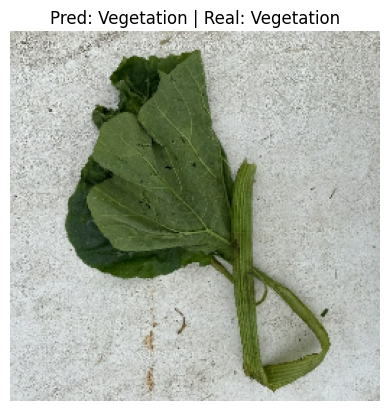

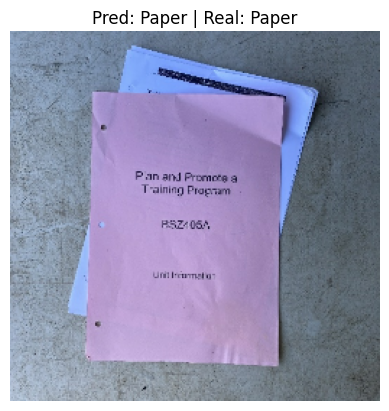

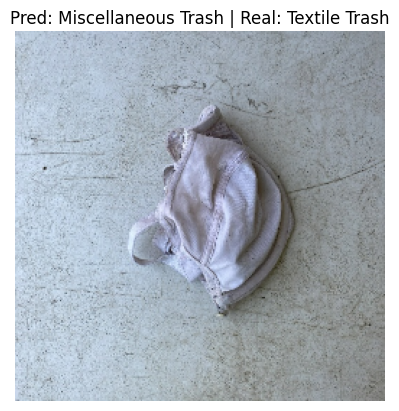

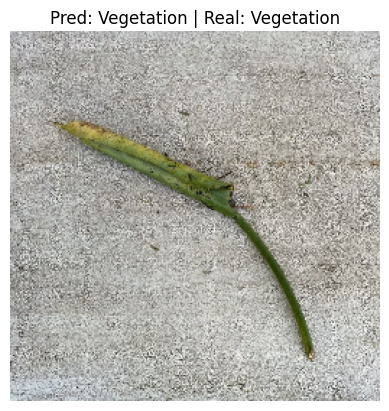

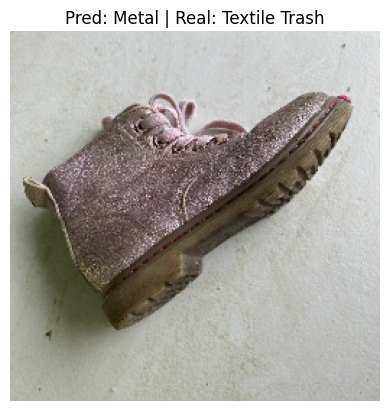

In [6]:
import matplotlib.pyplot as plt
import numpy as np

for images, labels in validation_dataset.take(1):  # coge un batch
    images = images.numpy()
    labels = labels.numpy()

idxs = np.random.choice(len(images), 5, replace=False)

for i in idxs:
    img = (images[i] * 255).astype("uint8")
    label = labels[i]

    img_input = np.expand_dims(images[i], axis=0)
    pred = np.argmax(model.predict(img_input, verbose=0))

    plt.imshow(img)
    plt.title(f"Pred: {class_names[pred]} | Real: {class_names[label]}")
    plt.axis("off")
    plt.show()